# Week 1: Engineering Baseline Analysis

Project: Culvert Exceedance Risk Assessment  
Author: Brice Nelson, PE, MBA  
Notebook: 01_baseline_analysis.ipynb  
Week 1: Engineering Baseline Analysis

In [1]:
# import libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from monte_carlo_drills.statistics.summary_statistics  import summary_stats

print("Libraries have been imported")

Libraries have been imported


In [2]:
# Project root
PROJECT_ROOT = Path.cwd().parents[2]

# Cleaned data directory
PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed" / "engineering" / "week_01"
)

# Input file
DATA_FILE = PROCESSED_DATA_DIR / "annual_peak_flows_clean.csv"

# Validate the file exists
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Cleaned data file not found: {DATA_FILE}")

print(f"Loading cleaned data from: {DATA_FILE}")

Loading cleaned data from: /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills/data/processed/engineering/week_01/annual_peak_flows_clean.csv


In [3]:
# Load Dataframe
df = pd.read_csv(DATA_FILE)

# Validate with head
df.head(5)

,water_year,peak_flow,units,status
0,2007,217.7,cfs,Final
1,2005,398.3,cfs,Final
2,2006,130.6,cfs,Final
3,2016,502.4,cfs,Final
4,2023,429.2,cfs,Final


In [4]:
# Check shape of the dataframe
print(f"Dataframe shape: {df.shape}")

Dataframe shape: (28, 4)


In [5]:
# Perform summary statistics
stats_df = summary_stats(df)

# Display summary statistics
stats_df

,minimum,maximum,mean,median
0,130.6,877.2,379.485714,379.8


In [6]:
required_columns = {"water_year", "peak_flow", "units", "status"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = df.copy()

for column in ["water_year", "peak_flow"]:
    df[column] = pd.to_numeric(df[column], errors="raise")

if df[["water_year", "peak_flow"]].isna().any().any():
    raise ValueError("Missing water years or peak flows.")

if not np.isfinite(df[["water_year", "peak_flow"]].to_numpy()).all():
    raise ValueError("Water years and peak flows must be finite.")

if (df["water_year"] % 1 != 0).any():
    raise ValueError("Water years must be whole numbers.")

if df["water_year"].duplicated().any():
    raise ValueError("Duplicate water years require review.")

if (df["peak_flow"] < 0).any():
    raise ValueError("Negative peak flows require review.")

if not df["units"].astype("string").str.strip().str.lower().eq("cfs").fillna(False).all():
    raise ValueError("Missing or inconsistent flow units.")

df["water_year"] = df["water_year"].astype(int)
df = df.sort_values("water_year").reset_index(drop=True)

print(df["status"].value_counts(dropna=False))

missing_years = sorted(
    set(range(df["water_year"].min(), df["water_year"].max() + 1))
    - set(df["water_year"])
)
print(f"Missing years within record: {missing_years}")

status
Final          27
Provisional     1
Name: count, dtype: int64
Missing years within record: [2001, 2019]


In [7]:
flows = df["peak_flow"]

summary = flows.describe().rename("peak_flow_cfs").to_frame()
summary.loc["median"] = flows.median()
summary.loc["sample_variance"] = flows.var(ddof=1)
summary.loc["skewness"] = flows.skew()

summary

,peak_flow_cfs
count,28.000000
mean,379.485714
std,151.912325
min,130.600000
25%,264.300000
50%,379.800000
75%,447.125000
max,877.200000
median,379.800000
sample_variance,23077.354603


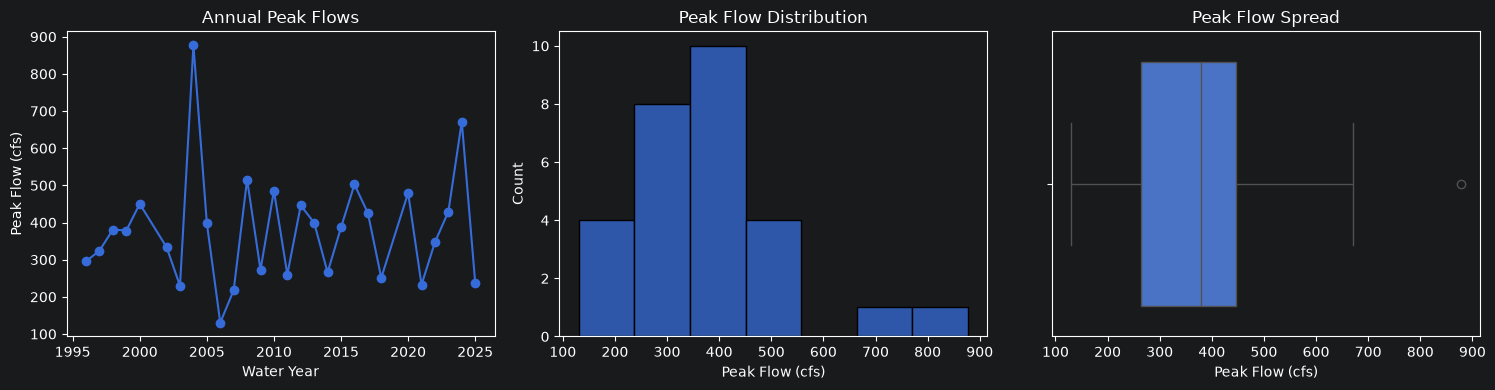

In [8]:
# Visualize the data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df["water_year"], flows, marker="o")
axes[0].set(
    title="Annual Peak Flows",
    xlabel="Water Year",
    ylabel="Peak Flow (cfs)",
)

sns.histplot(flows, bins="auto", ax=axes[1])
axes[1].set(
    title="Peak Flow Distribution",
    xlabel="Peak Flow (cfs)",
)

sns.boxplot(x=flows, ax=axes[2])
axes[2].set(
    title="Peak Flow Spread",
    xlabel="Peak Flow (cfs)",
)

plt.tight_layout()
plt.show()